### Importa los datos
Dataset con diferentes fármacos, sus efectos y ratings de los clientes.

Importa el dataset *drugLibTrain_raw.tsv*

In [1]:
# Importamos las librerias que vamos a necesitar a lo largo de todo el ejercicio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# De sklearn importamos KMeans (el algoritmo) y dos herramientas mas:
# - StandardScaler: para escalar los datos antes de aplicar K-Means
# - silhouette_score: la metrica que nos dira si nuestros clusters son buenos
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# El archivo es un .tsv (Tab Separated Values), igual que un csv pero los
# valores estan separados por tabuladores en vez de comas. Por eso le pasamos
# el parametro sep='\t' a pd.read_csv
df = pd.read_csv('data/drugLibTrain_raw.tsv', sep='\t')

# Vemos las primeras filas para entender que pinta tiene el dataset
df.head()

,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
2,1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
4,1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above


### Descriptive Analysis

Quedate únicamente con las columnas que podamos manejar: Columnas numéricas y columnas categóricas con pocas categorías (menos de 10)

In [2]:
# Antes de filtrar nada, miramos lo que tenemos:
# - shape: cuantas filas y columnas hay
# - info(): tipo de dato de cada columna y cuantos nulos
print('Forma del dataset:', df.shape)
df.info()

Forma del dataset: (3107, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3107 entries, 0 to 3106
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         3107 non-null   int64 
 1   urlDrugName        3107 non-null   object
 2   rating             3107 non-null   int64 
 3   effectiveness      3107 non-null   object
 4   sideEffects        3107 non-null   object
 5   condition          3106 non-null   object
 6   benefitsReview     3089 non-null   object
 7   sideEffectsReview  3032 non-null   object
 8   commentsReview     3095 non-null   object
dtypes: int64(2), object(7)
memory usage: 218.6+ KB


In [3]:
# Para cada columna de tipo objeto (texto/categorica), miramos cuantas categorias
# distintas tiene. Esto nos sirve para decidir cuales descartar.
# Ejemplo: si una columna tiene 500 categorias distintas (como 'urlDrugName'),
# generariamos 500 columnas dummy y eso seria un desastre. Por eso el enunciado
# pide quedarnos solo con las que tengan menos de 10 categorias.
for col in df.select_dtypes(include='object').columns:
    print(f'{col}: {df[col].nunique()} categorias unicas')

urlDrugName: 502 categorias unicas
effectiveness: 5 categorias unicas
sideEffects: 5 categorias unicas
condition: 1426 categorias unicas
benefitsReview: 3031 categorias unicas
sideEffectsReview: 2813 categorias unicas
commentsReview: 3046 categorias unicas


In [4]:
# Construimos la lista de columnas que nos interesan:
# 1) todas las numericas (int y float)
columnas_numericas = df.select_dtypes(include=np.number).columns.tolist()

# 2) las categoricas con menos de 10 categorias unicas
columnas_categoricas_pocas = [
    col for col in df.select_dtypes(include='object').columns
    if df[col].nunique() < 10
]

print('Columnas numericas:', columnas_numericas)
print('Columnas categoricas (<10 categorias):', columnas_categoricas_pocas)

# Nos quedamos solo con esas columnas y eliminamos las filas con NaN.
# K-Means no admite valores nulos, asi que los quitamos antes de seguir.
columnas_finales = columnas_numericas + columnas_categoricas_pocas
df_limpio = df[columnas_finales].copy().dropna()

print('Forma despues de filtrar:', df_limpio.shape)
df_limpio.head()

Columnas numericas: ['Unnamed: 0', 'rating']
Columnas categoricas (<10 categorias): ['effectiveness', 'sideEffects']
Forma despues de filtrar: (3107, 4)


,Unnamed: 0,rating,effectiveness,sideEffects
0,2202,4,Highly Effective,Mild Side Effects
1,3117,1,Highly Effective,Severe Side Effects
2,1146,10,Highly Effective,No Side Effects
3,3947,3,Marginally Effective,Mild Side Effects
4,1951,2,Marginally Effective,Severe Side Effects


#### Transforma las columnas categóricas

Transforma las columnas categoricas a numericas mediante dummies

In [5]:
# Por que necesitamos dummies?
# K-Means trabaja con DISTANCIAS entre puntos. Y no se pueden calcular distancias
# entre strings ('Highly Effective' vs 'Moderately Effective'). Necesitamos numeros.
#
# La solucion son las variables dummy (tambien llamado one-hot encoding):
# transformamos una columna con N categorias en N columnas de 0s y 1s, donde cada
# columna representa una categoria. Ejemplo:
#
#   effectiveness                       Highly  Moderately  Ineffective
#   Highly Effective         ---->        1        0            0
#   Moderately Effective     ---->        0        1            0
#   Ineffective              ---->        0        0            1
#
# Usamos drop_first=True para evitar redundancia: si tenemos 3 categorias, con
# 2 columnas ya se sabe a cual pertenece cada fila (si las dos son 0, es la tercera).
df_dummies = pd.get_dummies(df_limpio, drop_first=True)

# Convertimos todo a float porque sklearn a veces se queja con booleanos
df_dummies = df_dummies.astype(float)

print('Forma despues de hacer dummies:', df_dummies.shape)
df_dummies.head()

Forma despues de hacer dummies: (3107, 10)


,Unnamed: 0,rating,effectiveness_Highly Effective,effectiveness_Ineffective,effectiveness_Marginally Effective,effectiveness_Moderately Effective,sideEffects_Mild Side Effects,sideEffects_Moderate Side Effects,sideEffects_No Side Effects,sideEffects_Severe Side Effects
0,2202.0,4.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,3117.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1146.0,10.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,3947.0,3.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,1951.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


#### Evalua cual es la mejor K

Utiliza silhouette_score para evaluar cual es la mejor K.

#### Genera el K Means 

K = 2  ->  silhouette = 0.2437
K = 3  ->  silhouette = 0.2727
K = 4  ->  silhouette = 0.3371
K = 5  ->  silhouette = 0.3601
K = 6  ->  silhouette = 0.4049
K = 7  ->  silhouette = 0.4273


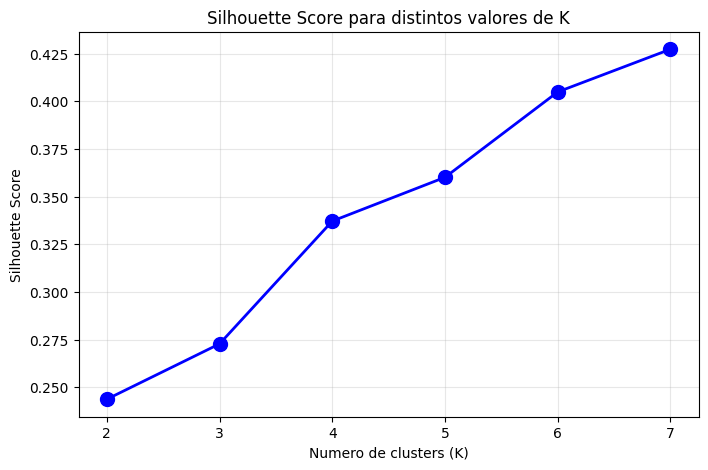


El mejor K es: 7


In [6]:
# IMPORTANTE: antes de entrenar K-Means tenemos que ESCALAR los datos.
# Por que? Porque K-Means usa distancias, y las distancias dependen de la escala.
# Imagina que tienes una columna 'rating' (de 1 a 10) y una columna dummy (0 o 1).
# La columna 'rating' tendria muchisimo mas peso en la distancia simplemente
# porque sus numeros son mas grandes, no porque sea mas importante.
#
# StandardScaler transforma cada columna para que tenga media 0 y desviacion 1.
# Asi todas las columnas pesan lo mismo en el calculo de distancias.
scaler = StandardScaler()
X_escalado = scaler.fit_transform(df_dummies)

# Ahora vamos a probar varios valores de K y ver cual da mejor silhouette.
# El silhouette_score va de -1 a 1:
#   - cerca de 1: clusters muy bien definidos y separados
#   - cerca de 0: clusters solapados
#   - negativo: las observaciones estan probablemente en el cluster equivocado
#
# Probamos de K=2 a K=7. Con K=1 no tiene sentido (es un solo cluster).
rango_k = range(2, 8)
silhouette_scores = []

for k in rango_k:
    # n_init=10 hace que K-Means se ejecute 10 veces con inicializaciones distintas
    # y se quede con la mejor. Asi evitamos caer en minimos locales malos.
    # random_state=42 fija la aleatoriedad para que los resultados sean reproducibles.
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = modelo.fit_predict(X_escalado)
    score = silhouette_score(X_escalado, etiquetas)
    silhouette_scores.append(score)
    print(f'K = {k}  ->  silhouette = {score:.4f}')

# Visualizamos los resultados para ver de un vistazo que K es el mejor
plt.figure(figsize=(8, 5))
plt.plot(list(rango_k), silhouette_scores, 'bo-', linewidth=2, markersize=10)
plt.xlabel('Numero de clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score para distintos valores de K')
plt.grid(True, alpha=0.3)
plt.show()

# Cogemos automaticamente el K que ha dado el mejor score
mejor_k = list(rango_k)[np.argmax(silhouette_scores)]
print(f'\nEl mejor K es: {mejor_k}')

In [7]:
# Ahora entrenamos el K-Means definitivo con el mejor K que hemos encontrado
kmeans_final = KMeans(n_clusters=mejor_k, random_state=42, n_init=10)

# fit_predict hace dos cosas a la vez:
#   1) entrena el modelo (encuentra los centroides)
#   2) devuelve la etiqueta de cluster de cada observacion
# Guardamos esa etiqueta como una columna nueva en nuestro dataframe.
df_dummies['cluster'] = kmeans_final.fit_predict(X_escalado)

# Vemos cuantas observaciones han caido en cada cluster
print('Observaciones por cluster:')
print(df_dummies['cluster'].value_counts().sort_index())

Observaciones por cluster:
cluster
0    238
1    846
2    787
3    348
4    454
5    247
6    187
Name: count, dtype: int64


Comprueba los resultados y muestra en un pie plot la distribución de los distintos clusters.

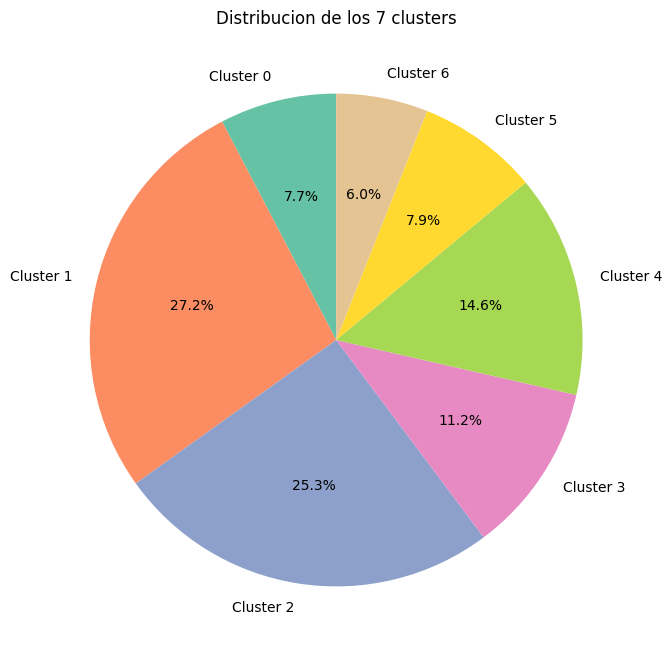


Perfil medio de cada cluster:


,Unnamed: 0,rating,effectiveness_Highly Effective,effectiveness_Ineffective,effectiveness_Marginally Effective,effectiveness_Moderately Effective,sideEffects_Mild Side Effects,sideEffects_Moderate Side Effects,sideEffects_No Side Effects,sideEffects_Severe Side Effects
cluster,,,,,,,,,,
0,1996.39,4.47,0.36,0.0,0.0,0.28,0.00,0.00,0.00,1.00
1,2012.49,8.68,0.57,0.0,0.0,0.00,1.00,0.00,0.00,0.00
2,2081.77,9.30,0.68,0.0,0.0,0.00,0.00,0.00,1.00,0.00
3,2086.69,5.80,0.00,0.0,0.0,1.00,0.34,0.35,0.23,0.00
4,2110.01,6.63,0.50,0.0,0.0,0.00,0.00,0.89,0.00,0.00
5,2165.45,1.56,0.00,1.0,0.0,0.00,0.08,0.19,0.12,0.31
6,2296.29,3.40,0.00,0.0,1.0,0.00,0.20,0.23,0.19,0.29


In [8]:
# Calculamos el conteo de cada cluster y lo guardamos para usarlo en el pie plot
distribucion = df_dummies['cluster'].value_counts().sort_index()

# Pintamos el pie plot:
#   - autopct='%1.1f%%' muestra el porcentaje con un decimal
#   - startangle=90 hace que el primer trozo empiece arriba (mas estetico)
plt.figure(figsize=(8, 8))
plt.pie(
    distribucion,
    labels=[f'Cluster {i}' for i in distribucion.index],
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set2', n_colors=mejor_k)
)
plt.title(f'Distribucion de los {mejor_k} clusters')
plt.show()

# Bonus: vemos las medias de cada cluster para interpretar que tipo de
# observaciones contiene cada uno. Esto es muy util para dar sentido al clustering:
# por ejemplo, podriamos descubrir que el Cluster 0 son farmacos con rating alto
# y pocos efectos secundarios, y el Cluster 1 son farmacos con rating bajo, etc.
print('\nPerfil medio de cada cluster:')
df_dummies.groupby('cluster').mean().round(2)